# UPF Prophet v3 (shared version)

This notebook does not read the original Excel dataset.
It loads a serialized Prophet bundle stored in the same folder, so the shared repo can be copied and executed as-is.

In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import pandas as pd

MODEL_BUNDLE = Path("upf_prophet_model.pkl")
MODEL_BUNDLE.resolve()

PosixPath('/home/i2catf495/Documents/i2catProjects/O-RAN/BeGreen/MLStrategy/protectted/repo/FinalScripts/6gsmartez_models/upf_prophet_model.pkl')

In [2]:
if not MODEL_BUNDLE.exists():
    raise FileNotFoundError(f"Pickle bundle not found: {MODEL_BUNDLE.resolve()}")

with MODEL_BUNDLE.open("rb") as fh:
    bundle = pickle.load(fh)

model = bundle["model"]
reference_forecast = bundle["reference_forecast"].copy()
metadata = {k: v for k, v in bundle.items() if k not in {"model", "reference_forecast"}}

metadata

{'artifact_type': 'prophet_model_bundle',
 'created_at_utc': '2026-03-13T13:00:56.907699+00:00',
 'model_type': 'Prophet',
 'frequency': '15min',
 'training_days': 30,
 'test_rows': 2873,
 'future_periods': 2874,
 'shared_note': 'Raw source data is intentionally excluded from this artifact.',
 'train_range': {'start': '2023-09-02T00:00:00',
  'end': '2023-10-02T00:00:00',
  'rows': 2880},
 'forecast_reference_range': {'start': '2023-09-02T00:00:00',
  'end': '2023-10-31T22:30:00',
  'rows': 5754}}

In [3]:
forecast_shared = reference_forecast.copy()

print(f"test_rows = {bundle['test_rows']}")
print(f"future_periods = {bundle['future_periods']}")
print(f"forecast_shared rows = {len(forecast_shared)}")
print("Expected formula: future_periods = x_test.shape[0] + 1")

forecast_shared.tail()

test_rows = 2873
future_periods = 2874
forecast_shared rows = 5754
Expected formula: future_periods = x_test.shape[0] + 1


,ds,yhat,yhat_lower,yhat_upper
5749,2023-10-31 21:30:00,89080.719616,66805.628875,110177.906439
5750,2023-10-31 21:45:00,88706.826808,65841.691986,110055.625101
5751,2023-10-31 22:00:00,88005.215318,64008.596213,108833.364097
5752,2023-10-31 22:15:00,86949.014351,62502.376893,108480.293869
5753,2023-10-31 22:30:00,85520.830253,62903.735058,107010.443973


In [4]:
# Optional verification: rebuild the forecast from the serialized model using the same horizon.
def forecast_from_bundle(model, periods, freq="15min"):
    future = model.make_future_dataframe(periods=periods, freq=freq)
    forecast = model.predict(future)
    return forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()


forecast_rebuilt = forecast_from_bundle(model, periods=bundle["future_periods"], freq=bundle["frequency"])
print(f"rebuilt rows = {len(forecast_rebuilt)}")
forecast_rebuilt.tail()

rebuilt rows = 5754


,ds,yhat,yhat_lower,yhat_upper
5749,2023-10-31 21:30:00,89080.719616,67756.210521,111763.720236
5750,2023-10-31 21:45:00,88706.826808,66965.778581,111101.073558
5751,2023-10-31 22:00:00,88005.215318,66500.516472,110561.836214
5752,2023-10-31 22:15:00,86949.014351,64138.066197,109607.663154
5753,2023-10-31 22:30:00,85520.830253,65164.806304,107868.035764


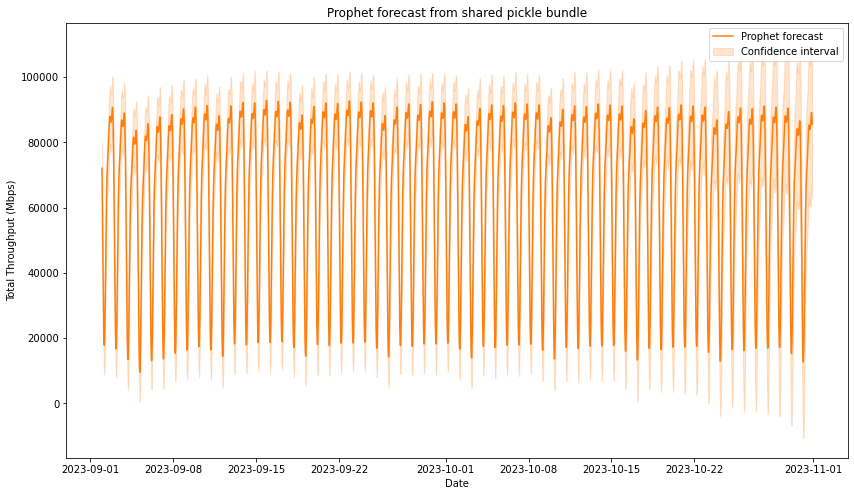

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))
x_values = pd.to_datetime(forecast_shared["ds"]).to_numpy()
yhat_values = forecast_shared["yhat"].to_numpy()
lower_values = forecast_shared["yhat_lower"].to_numpy()
upper_values = forecast_shared["yhat_upper"].to_numpy()

ax.plot(x_values, yhat_values, label="Prophet forecast", color="tab:orange")
ax.fill_between(
    x_values,
    lower_values,
    upper_values,
    color="tab:orange",
    alpha=0.2,
    label="Confidence interval",
)
ax.set_title("Prophet forecast from shared pickle bundle")
ax.set_xlabel("Date")
ax.set_ylabel("Total Throughput (Mbps)")
ax.legend()
plt.show()

In [6]:
OUTPUT_CSV = Path("prophet_shared_forecast.csv")
forecast_shared.to_csv(OUTPUT_CSV, index=False)
OUTPUT_CSV.resolve()

PosixPath('/home/i2catf495/Documents/i2catProjects/O-RAN/BeGreen/MLStrategy/protectted/repo/FinalScripts/6gsmartez_models/prophet_shared_forecast.csv')

## Notes

- The original oracle values are not included in the shared pickle.
- Evaluation against the protected dataset stays in the private training area.
- `forecast_shared` is the exact forecast generated privately with `future_periods = x_test.shape[0] + 1`.
- Keep `UPF_Phrophetv3.ipynb` and `upf_prophet_model.pkl` together in the same folder when sharing.